In [37]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning
#from .test_cclobject import check_eq_repr_hash
from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation

In [ ]:

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':50,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#set up lens source sample
srcs_nzs = np.loadtxt('/home/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/fiducial.nz')
lens_nzs = np.loadtxt('/home/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))


#calculate the power spectrum for calculation of correlation function
logLMIN = np.log(20)
logLMAX = np.log(100000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(20+NCell)
for i in range(20):
    ells[i] = i
for i in range(NCell):
    ells[i+20] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]
# np.save('/home/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/ells4Cell.npy', ells)
corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa,
                                    l_limber=160,
                                    limber_max_error=0.000001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 500,
                                    p_of_k_a_lin = pk2_lin_cocoa))
    
#calculate the correlation function
tmin = 1.
tmax = 500.
ntheta = 20

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

ncombo1 = int(nsrcs*(nsrcs+1)/2)
ncombo2 = int(nsrcs*nlens)
ncombo3 = int(nlens)

xip, xim, gammat, wtheta = [],[],[],[]
for i in range(ncombo1):
    xip.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG+', method='FFTLog'))
    xim.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='GG-', method='FFTLog'))
xip = np.concatenate(xip)
xim = np.concatenate(xim)

for i in range(ncombo1, ncombo1+ncombo2):
    gammat.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NG', method='FFTLog'))
gammat = np.concatenate(gammat)

for i in range(ncombo1 + ncombo2, ncombo1 + ncombo2 + ncombo3):
    wtheta.append(correlation(COSMO, ell=ells, C_ell=corrs[i], theta=thetas, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)
 
dv_ccl = np.concatenate((xip,xim,gammat,wtheta))

chi2 of {wtheta} is 0.037873384451881834


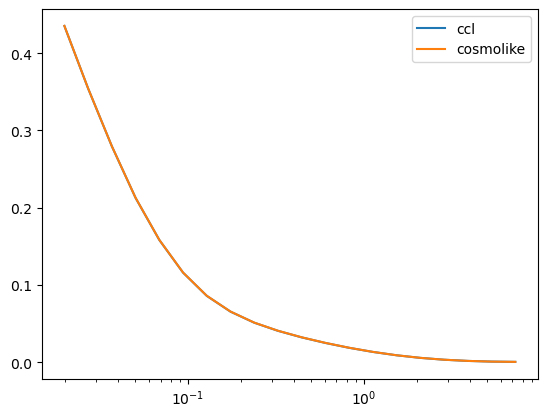

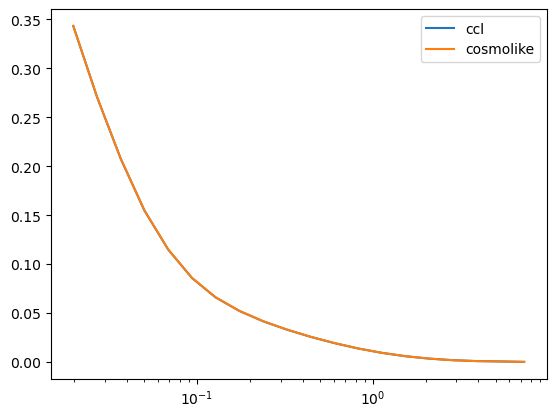

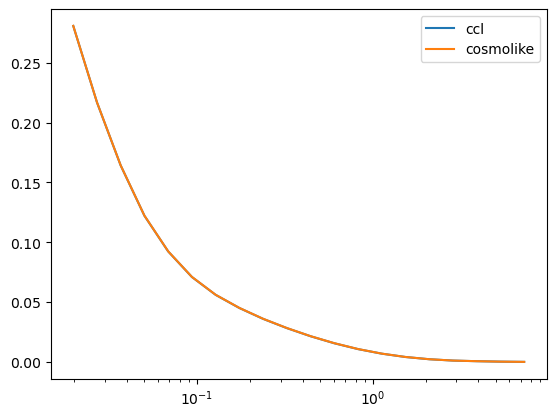

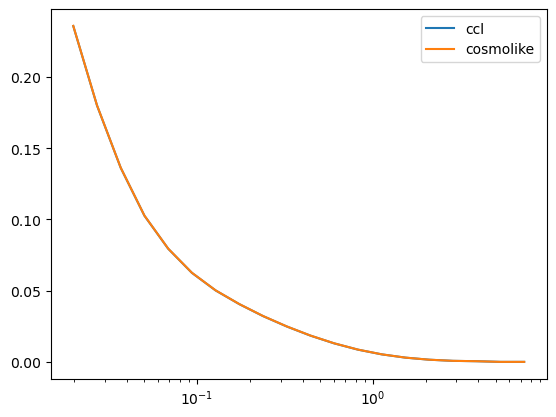

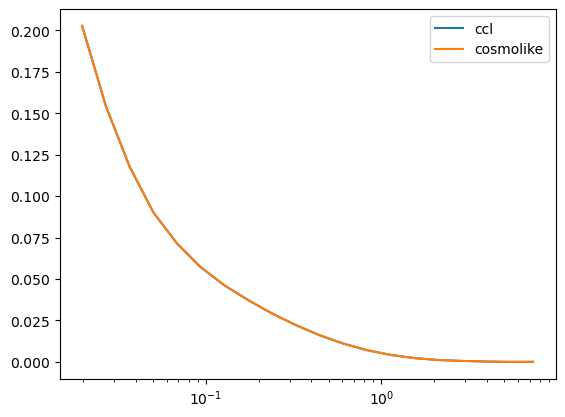

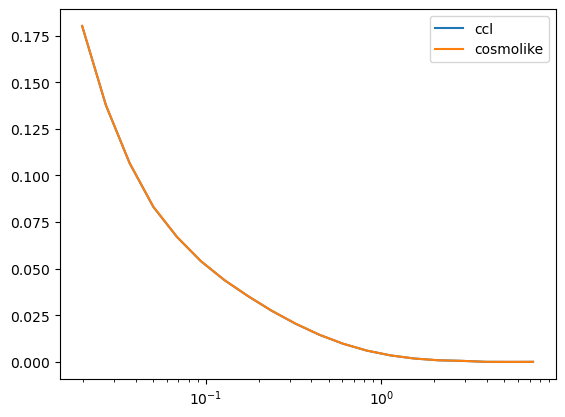

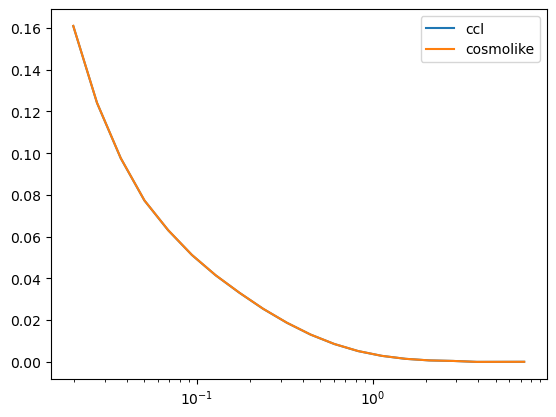

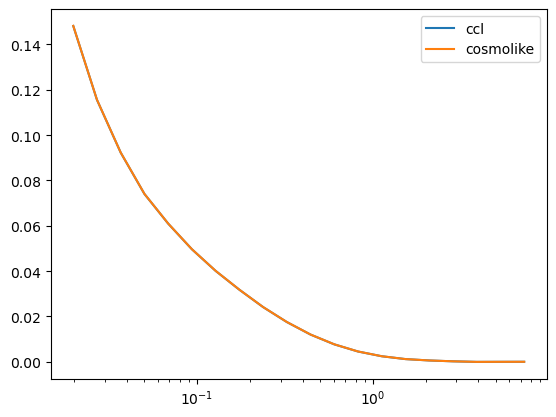

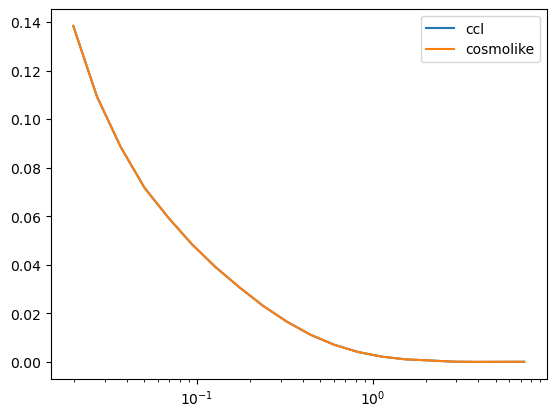

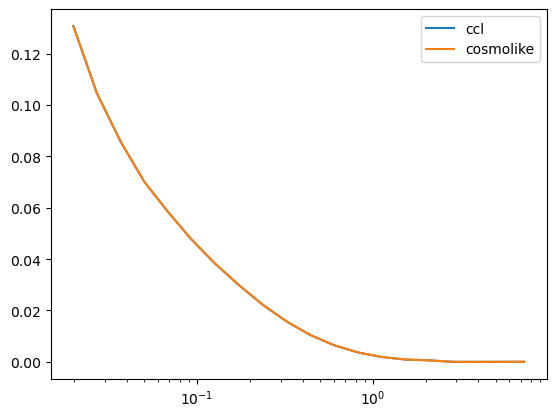

In [ ]:
#load covariance matrix and dv from cosmolike
cov_file = '/home/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman'
mask_file = '/home/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask'
mask = np.loadtxt(mask_file)[:,1].astype(bool)
cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

dv_cosmolike = np.loadtxt('/home/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber+noRSD+takahashi_evaluate/roman.modelvector')[:,1]

In [ ]:
import importlib
import utils
importlib.reload(utils)